In [21]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# We Use weight-height Dataset for this
df = pd.read_csv("C:/Users/Admin/Machine Learning Algorithms/Datasets/weight-height.csv")


In [ ]:

df.head()

  Gender     Height      Weight
0   Male  73.847017  241.893563
1   Male  68.781904  162.310473
2   Male  74.110105  212.740856
3   Male  71.730978  220.042470
4   Male  69.881796  206.349801


,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [25]:
# Features
X = df[["Height"]]

y = df["Weight"]

In [27]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [28]:
print(type(X_train))


<class 'pandas.DataFrame'>


In [10]:
# Feature Scaling
Scaler = StandardScaler()
X_train = Scaler.fit(X_train)
X_test = Scaler.transform(X_test)

In [29]:
# Ridge Model

from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None


In [32]:
#Prediction 
y_pred = ridge_model.predict(X_test)


print(y_pred[:10])   # first 10 predictions


[179.25174984 180.34610579 161.622851   204.21994561 166.58840438
 153.24629057 158.90674888 164.40254707 132.3622069  140.04654292]


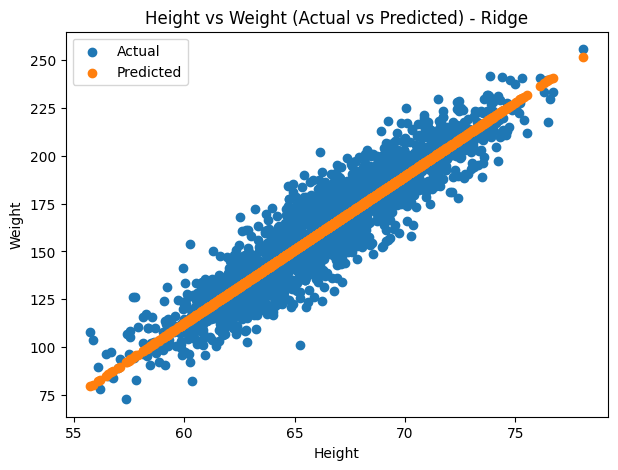

In [33]:
# Prediction 
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.scatter(X_test["Height"], y_test, label="Actual")
plt.scatter(X_test["Height"], y_pred, label="Predicted")

plt.xlabel("Height")
plt.ylabel("Weight")
plt.title("Height vs Weight (Actual vs Predicted) - Ridge")
plt.legend()
plt.show()

In [35]:
# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nRidge Regression Results")
print("MSE:", mse)
print("R2 Score:", r2)

print("Coefficient:", ridge_model.named_steps["ridge"].coef_)
print("Intercept:", ridge_model.named_steps["ridge"].intercept_)


Ridge Regression Results
MSE: 149.0056738824572
R2 Score: 0.8577297060809331
Coefficient: [29.61533248]
Intercept: 161.3267623130613


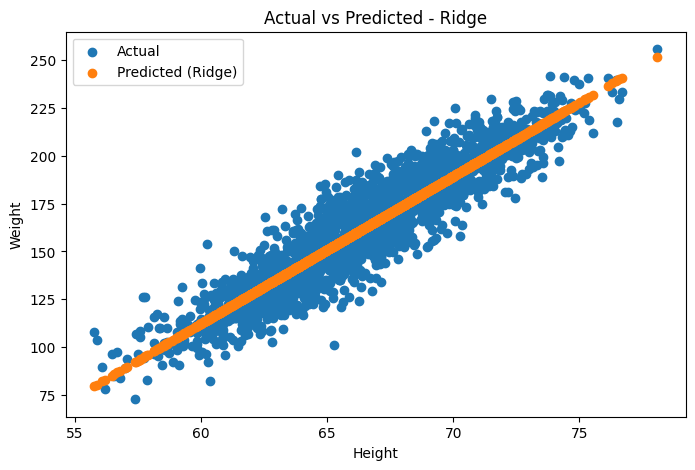

In [ ]:
# Visualize 
# Actual V/S Ridge 
y_pred_ridge = ridge_model.predict(X_test)

plt.figure(figsize=(8,5))
plt.scatter(X_test["Height"], y_test, label="Actual")
plt.scatter(X_test["Height"], y_pred_ridge, label="Predicted (Ridge)")

plt.xlabel("Height")
plt.ylabel("Weight")
plt.title("Actual vs Predicted - Ridge")
plt.legend()
plt.show()
